# Libraries

In [81]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [82]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240524 - Ag60 GDE_0.9 M Na2SO4_pH3

11-Aug-26  08:01 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
07-Jun-26  12:55 PM    <DIR>          .ipynb_checkpoints
27-May-24  02:08 PM           110,661 0p9M_pH3 Na2SO4_20240527_1208_1min - Copy.xlsx
03-Aug-26  03:57 PM            79,065 0p9M_pH3 Na2SO4_20240527_1208_1min.xlsx
27-May-24  02:08 PM            26,807 0p9M_pH3 Na2SO4_20240527_1208_5min.xlsx
27-May-24  02:08 PM           479,886 0p9M_pH3 Na2SO4_20240527_1208_Line_1.csv
11-Aug-26  07:54 AM             1,411 20240424_0.9M Na2SO4_pH3_flow rate.csv
19-Jul-25  05:40 PM           838,176 20240524 - Ag60 GDE_0.9 M Na2SO4_pH3.ipynb
11-Aug-26  08:01 AM           836,572 20240524 - Ag60 GDE_0.9 M Na2SO4_pH3-CORRECTED.ipynb
11-Aug-26  07:55 AM               599 20240524_0.9 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  07:59 AM        

# Load Data

In [83]:
Book = "Book_20240524 - Ag60 GDE_0.9 M Na2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,53.142014,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-24 15:48:11.587,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000
1,Ag60 GDE in PTFE holder,60,55.016881,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:04:16.000,0.267892,0.073234,...,0.000679,0.012581,0.978723,0.002191,0.038017,0.704696,NaN,0.742713,0.012692,106.9603
2,Ag60 GDE in PTFE holder,60,56.430463,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:29:47.000,0.693170,0.095840,...,0.000887,0.015979,0.980474,0.000860,0.050963,0.918023,NaN,0.968986,0.016036,NaN
3,Ag60 GDE in PTFE holder,60,57.546487,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:55:18.000,1.118448,0.102122,...,0.000943,0.015629,0.981669,0.000591,0.055248,0.915699,NaN,0.970947,0.015672,108.0033
4,Ag60 GDE in PTFE holder,60,59.276602,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 17:20:49.000,1.543726,0.105963,...,0.000978,0.015243,0.982001,0.000537,0.059027,0.919895,NaN,0.978921,0.015285,NaN
5,Ag60 GDE in PTFE holder,60,59.215277,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 17:56:50.000,2.144004,0.146119,...,0.001353,0.022596,0.975068,0.000310,0.039269,0.655906,NaN,0.695174,0.022649,107.7571
6,Ag60 GDE in PTFE holder,60,60.668827,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:22:20.000,2.569004,0.174282,...,0.001627,0.030526,0.967055,0.000241,0.048387,0.907841,NaN,0.956228,0.030601,NaN
7,Ag60 GDE in PTFE holder,60,60.912000,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:47:50.000,2.994004,0.171676,...,0.001603,0.030643,0.967272,0.000150,0.047871,0.914949,NaN,0.962821,0.030707,106.8559
8,Ag60 GDE in PTFE holder,60,61.499812,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 19:13:20.000,3.419004,0.170419,...,0.001591,0.030644,0.967315,0.000131,0.047960,0.923824,NaN,0.971784,0.030707,NaN
9,Ag60 GDE in PTFE holder,60,61.470190,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.52,2024-05-24 19:49:22.000,4.019559,0.171752,...,0.001603,0.030705,0.967334,0.000100,0.025080,0.480406,NaN,0.505487,0.030766,106.9331


In [84]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
35,Ag60 GDE in PTFE holder,60,68.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-25 07:55:42,16.13,17.871893,...,0.048143,0.775581,0.002035,3.149548,0.870380,NaN,4.019928,0.058445,NaN,68.30
36,Ag60 GDE in PTFE holder,60,68.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-25 08:21:12,16.55,12.152880,...,0.047062,0.835135,0.000662,2.134168,0.857409,NaN,2.991576,0.053347,91.524,68.83
37,Ag60 GDE in PTFE holder,60,69.99,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-25 08:57:12,17.15,12.091386,...,0.043893,0.838954,0.000688,2.157672,0.813177,NaN,2.970850,0.049718,NaN,69.99


#### Temp from pH meter

In [85]:
Temp = "2024-05-25_172536.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.67849462365591
Temp C median: 24.0


## Power supply

In [86]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.21V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,24.05.2024 15:48:11.587
1,40.00V,3.34V,0.100A,0.111A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,24.05.2024 15:49:11.592


In [87]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.21V
0.100A 1    3.34V
       2    3.34V

In [88]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-24 14:00:00     0.117      3.37
1 2024-05-24 16:00:00     0.266      3.86
2 2024-05-24 18:00:00     0.512      4.64
3 2024-05-24 20:00:00     0.770      5.34
4 2024-05-24 22:00:00     1.013      5.99
5 2024-05-25 00:00:00     1.509      7.10
6 2024-05-25 02:00:00     2.013      7.91
7 2024-05-25 04:00:00     3.009      9.45
8 2024-05-25 06:00:00     3.013      9.62
9 2024-05-25 08:00:00     1.510      6.64


In [89]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-2].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-24 14:00:00     0.117      3.37
1 2024-05-24 16:00:00     0.266      3.86
2 2024-05-24 18:00:00     0.512      4.64
3 2024-05-24 20:00:00     0.770      5.34
4 2024-05-24 22:00:00     1.013      5.99
5 2024-05-25 00:00:00     1.509      7.10
6 2024-05-25 02:00:00     2.013      7.91
7 2024-05-25 04:00:00     3.009      9.45


In [90]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [91]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.117,3.37
0.266,3.86
0.512,4.64
0.770,5.34
1.013,5.99
1.509,7.10
2.013,7.91
3.009,9.45


In [92]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.117,3.37,1.17
0.266,3.86,2.66
0.512,4.64,5.12
0.770,5.34,7.70
1.013,5.99,10.13
1.509,7.10,15.09
2.013,7.91,20.13
3.009,9.45,30.09


## Flow rate

In [93]:
flow_rate = "0p9M_pH3 Na2SO4_20240527_1208_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-27 12:08:41.597000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p9M_pH3 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [94]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-24 15:47:59.971000,59.07438,29.53719
1,2024-05-24 15:49:00.019000,59.886588,29.943294
2,2024-05-24 15:49:59.981000,59.681488,29.840744
3,2024-05-24 15:51:00.029000,60.054625,30.027312
4,2024-05-24 15:51:59.990000,59.559167,29.779583
...,...,...,...
937,2024-05-25 07:25:00.019000,18.416542,9.208271
938,2024-05-25 07:25:59.981000,18.418513,9.209256
939,2024-05-25 07:27:00.029000,18.612419,9.306209
940,2024-05-25 07:27:59.990000,18.529193,9.264597


In [95]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

### Correction for dry flow

In [96]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.382 L/mol
p_sat = 2.9845 kPa -> x(H2O) = 2.95 % -> dry factor 0.97055


In [97]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [98]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-24 14:00:00      59.07438     60.296135      59.732335   
1 2024-05-24 16:00:00     59.605455     62.118571      60.922607   
2 2024-05-24 18:00:00      61.12965     62.941419      61.908755   
3 2024-05-24 20:00:00     61.819925     64.574989      62.494301   
4 2024-05-24 22:00:00     62.987943     68.485334      64.390955   
5 2024-05-25 00:00:00     67.651459     73.850507      68.819755   
6 2024-05-25 02:00:00     72.628555     83.630815      74.229402   
7 2024-05-25 04:00:00     67.951173     83.488362      81.329719   
8 2024-05-25 06:00:00     17.234653     70.465385      55.112614   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        59.716719         57.334368         58.520136          57.972943   
1        60.947742           57.8498         60.288893          59.128155   
2         61.87891         59.329101         61.087505          60.085258   
3        62

In [99]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-24 14:00:00,59.07438,60.296135,59.732335,59.716719,57.334368,58.520136,57.972943,57.957787,0.117,3.37
1,2024-05-24 16:00:00,59.605455,62.118571,60.922607,60.947742,57.8498,60.288893,59.128155,59.152551,0.266,3.86
2,2024-05-24 18:00:00,61.12965,62.941419,61.908755,61.87891,59.329101,61.087505,60.085258,60.056291,0.512,4.64
3,2024-05-24 20:00:00,61.819925,64.574989,62.494301,62.353185,59.999044,62.672958,60.653556,60.516597,0.770,5.34
4,2024-05-24 22:00:00,62.987943,68.485334,64.390955,64.011939,61.132658,66.468126,62.494345,62.126493,1.013,5.99
5,2024-05-25 00:00:00,67.651459,73.850507,68.819755,68.357374,65.658812,71.67527,66.792697,66.343935,1.509,7.10
6,2024-05-25 02:00:00,72.628555,83.630815,74.229402,73.36512,70.48931,81.167503,72.043004,71.20418,2.013,7.91
7,2024-05-25 04:00:00,67.951173,83.488362,81.329719,82.577968,65.949698,81.029246,78.934185,80.145667,3.009,9.45


In [102]:
# dfflow_rate.to_csv('20240424_0.9M Na2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [103]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.117,3.37,1.17,117.0
0.266,3.86,2.66,266.0
0.512,4.64,5.12,512.0


In [104]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.117,3.37,1.17,117.0,2838.888
0.266,3.86,2.66,266.0,7392.672
0.512,4.64,5.12,512.0,17104.896
0.770,5.34,7.70,770.0,29604.960
1.013,5.99,10.13,1013.0,43688.664
1.509,7.10,15.09,1509.0,77140.080
2.013,7.91,20.13,2013.0,114644.376
3.009,9.45,30.09,3009.0,204732.360


In [105]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.117,3.37,1.17,117.0,2838.888,0.000789
0.266,3.86,2.66,266.0,7392.672,0.002054
0.512,4.64,5.12,512.0,17104.896,0.004751
0.770,5.34,7.70,770.0,29604.960,0.008224
1.013,5.99,10.13,1013.0,43688.664,0.012136
1.509,7.10,15.09,1509.0,77140.080,0.021428
2.013,7.91,20.13,2013.0,114644.376,0.031846
3.009,9.45,30.09,3009.0,204732.360,0.056870


In [108]:
# dfcell_voltage.to_csv('20240524_0.9 M Na2SO4_pH3_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [109]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,53.14,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-24 15:48:11.587,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,53.14,0.0
1,Ag60 GDE in PTFE holder,60,55.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:04:16.000,0.27,0.073234,...,0.978723,0.002191,0.038017,0.704696,NaN,0.742713,0.012692,106.9603,55.02,0.0
2,Ag60 GDE in PTFE holder,60,56.43,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:29:47.000,0.69,0.095840,...,0.980474,0.000860,0.050963,0.918023,NaN,0.968986,0.016036,NaN,56.43,0.0
3,Ag60 GDE in PTFE holder,60,57.55,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:55:18.000,1.12,0.102122,...,0.981669,0.000591,0.055248,0.915699,NaN,0.970947,0.015672,108.0033,57.55,1.0
4,Ag60 GDE in PTFE holder,60,59.28,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 17:20:49.000,1.54,0.105963,...,0.982001,0.000537,0.059027,0.919895,NaN,0.978921,0.015285,NaN,59.28,1.0
5,Ag60 GDE in PTFE holder,60,59.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 17:56:50.000,2.14,0.146119,...,0.975068,0.000310,0.039269,0.655906,NaN,0.695174,0.022649,107.7571,59.22,2.0
6,Ag60 GDE in PTFE holder,60,60.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:22:20.000,2.57,0.174282,...,0.967055,0.000241,0.048387,0.907841,NaN,0.956228,0.030601,NaN,60.67,2.0
7,Ag60 GDE in PTFE holder,60,60.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:47:50.000,2.99,0.171676,...,0.967272,0.000150,0.047871,0.914949,NaN,0.962821,0.030707,106.8559,60.91,2.0
8,Ag60 GDE in PTFE holder,60,61.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 19:13:20.000,3.42,0.170419,...,0.967315,0.000131,0.047960,0.923824,NaN,0.971784,0.030707,NaN,61.50,3.0
9,Ag60 GDE in PTFE holder,60,61.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.52,2024-05-24 19:49:22.000,4.02,0.171752,...,0.967334,0.000100,0.025080,0.480406,NaN,0.505487,0.030766,106.9331,61.47,4.0


## Current Density

In [110]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,53.14,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-24 15:48:11.587,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0000,53.14,0.0,0.0
1,Ag60 GDE in PTFE holder,60,55.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:04:16.000,0.27,0.073234,...,0.002191,0.038017,0.704696,NaN,0.742713,0.012692,106.9603,55.02,0.0,-130.0
2,Ag60 GDE in PTFE holder,60,56.43,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:29:47.000,0.69,0.095840,...,0.000860,0.050963,0.918023,NaN,0.968986,0.016036,NaN,56.43,0.0,-130.0
3,Ag60 GDE in PTFE holder,60,57.55,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 16:55:18.000,1.12,0.102122,...,0.000591,0.055248,0.915699,NaN,0.970947,0.015672,108.0033,57.55,1.0,-130.0
4,Ag60 GDE in PTFE holder,60,59.28,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-24 17:20:49.000,1.54,0.105963,...,0.000537,0.059027,0.919895,NaN,0.978921,0.015285,NaN,59.28,1.0,-130.0
5,Ag60 GDE in PTFE holder,60,59.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 17:56:50.000,2.14,0.146119,...,0.000310,0.039269,0.655906,NaN,0.695174,0.022649,107.7571,59.22,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,60.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:22:20.000,2.57,0.174282,...,0.000241,0.048387,0.907841,NaN,0.956228,0.030601,NaN,60.67,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,60.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 18:47:50.000,2.99,0.171676,...,0.000150,0.047871,0.914949,NaN,0.962821,0.030707,106.8559,60.91,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,61.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-24 19:13:20.000,3.42,0.170419,...,0.000131,0.047960,0.923824,NaN,0.971784,0.030707,NaN,61.50,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.52,2024-05-24 19:49:22.000,4.02,0.171752,...,0.000100,0.025080,0.480406,NaN,0.505487,0.030766,106.9331,61.47,4.0,-520.0


## FE(CO)

In [111]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [112]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.382 L/mol


In [113]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.117, 0.266, 0.512, 0.77, 1.013, 1.509, 2.013, 3.009]

In [114]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[5, 4, 5, 4, 4, 5, 4, 4]

In [115]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.117                0.001  0.015
0.266                0.002  0.031
0.512                0.004  0.055
0.770                0.011  0.072
1.013                0.030  0.077
1.509                0.079  0.077
2.013                0.137  0.068
3.009                0.225  0.056


In [116]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 110.2 / 87.9 %


In [117]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60,56.43,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 16:29:47,0.69,0.095840,...,56.43,0.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,110.207298
3,Ag60 GDE in PTFE holder,60,57.55,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 16:55:18,1.12,0.102122,...,57.55,1.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,108.288689
4,Ag60 GDE in PTFE holder,60,59.28,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 17:20:49,1.54,0.105963,...,59.28,1.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,105.991479


In [119]:
rows = rows.drop(rows[rows['FE(total)'] > 105].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60,53.14,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 15:48:11.587,0.00,0.000000,...,53.14,0.0,-117.0,0.00,0.117,57.972943,57.334368,58.520136,57.957787,0.000000
1,Ag60 GDE in PTFE holder,60,55.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 16:04:16.000,0.27,0.073234,...,55.02,0.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,86.642623
5,Ag60 GDE in PTFE holder,60,59.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 17:56:50.000,2.14,0.146119,...,59.22,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,70.251043
6,Ag60 GDE in PTFE holder,60,60.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:22:20.000,2.57,0.174282,...,60.67,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.316698
7,Ag60 GDE in PTFE holder,60,60.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:47:50.000,2.99,0.171676,...,60.91,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.587824
8,Ag60 GDE in PTFE holder,60,61.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 19:13:20.000,3.42,0.170419,...,61.50,3.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.555952
9,Ag60 GDE in PTFE holder,60,61.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 19:49:22.000,4.02,0.171752,...,61.47,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,49.988957
10,Ag60 GDE in PTFE holder,60,62.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:14:51.000,4.44,0.376590,...,62.11,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,88.809556
11,Ag60 GDE in PTFE holder,60,61.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:40:23.000,4.87,0.420141,...,61.91,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,91.984880
12,Ag60 GDE in PTFE holder,60,61.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 21:05:53.000,5.29,0.416608,...,61.83,5.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,92.104394


In [120]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [121]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 1.54].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.14].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.02].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.07].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,55.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 16:04:16,0.27,0.073234,...,55.02,0.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,86.642623
6,Ag60 GDE in PTFE holder,60,60.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:22:20,2.57,0.174282,...,60.67,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.316698
7,Ag60 GDE in PTFE holder,60,60.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:47:50,2.99,0.171676,...,60.91,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.587824
8,Ag60 GDE in PTFE holder,60,61.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 19:13:20,3.42,0.170419,...,61.50,3.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.555952
10,Ag60 GDE in PTFE holder,60,62.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:14:51,4.44,0.376590,...,62.11,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,88.809556
11,Ag60 GDE in PTFE holder,60,61.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:40:23,4.87,0.420141,...,61.91,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,91.984880
12,Ag60 GDE in PTFE holder,60,61.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 21:05:53,5.29,0.416608,...,61.83,5.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,92.104394
13,Ag60 GDE in PTFE holder,60,61.89,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 21:41:55,5.90,0.412928,...,61.89,5.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,91.421550
14,Ag60 GDE in PTFE holder,60,62.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.770,2024-05-24 22:58:28,7.17,1.223745,...,62.67,7.0,-770.0,0.77,0.770,60.653556,59.999044,62.672958,60.516597,88.086070
15,Ag60 GDE in PTFE holder,60,62.33,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.770,2024-05-24 23:34:29,7.77,1.341958,...,62.33,7.0,-770.0,0.77,0.770,60.653556,59.999044,62.672958,60.516597,86.986844


### Mean FE per current density

In [122]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        117    4.434986   82.207637      4.434986     82.207637        NaN   
1        266    4.714043   89.772782      4.702906     89.884919   0.031105   
2        512    5.915577   85.164518      6.033115     85.644645   0.145701   
3        770   11.491386   74.760972     11.682518     74.867179   0.779006   
4       1013   23.292627   62.488031     24.208790     62.490891   1.735232   
5       1509   46.842203   44.744225     47.030817     44.417768   1.575220   
6       2013   63.676783   31.566220     63.946606     31.625146   1.509709   
7       3009   78.498702   19.382839     79.206318     19.510876   1.479708   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0        NaN        NaN        NaN   4.434986  ...   0.000679     0.000679  1   
1   0.114357   0.053875   0.198072   4.684756  ...   0.001607     0.001603  3   
2   0.626895   0.291402   1.253789   5.874307

## FE(H2)

In [123]:
print(rows["FE(H2)"])

1      4.434986
6      4.772616
7      4.702906
8      4.666607
10     5.483511
11     6.112567
12     6.061657
13     6.004573
14    12.031637
15    13.156635
16     9.443872
17    11.333399
18    18.389187
19    23.509441
20    24.908139
21    26.363741
22    50.238324
23    45.628525
24    48.433109
26    43.068854
27    59.958478
28    62.666886
29    65.226327
30    66.855443
31    80.128154
32    74.431624
33    78.284481
34    81.150550
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

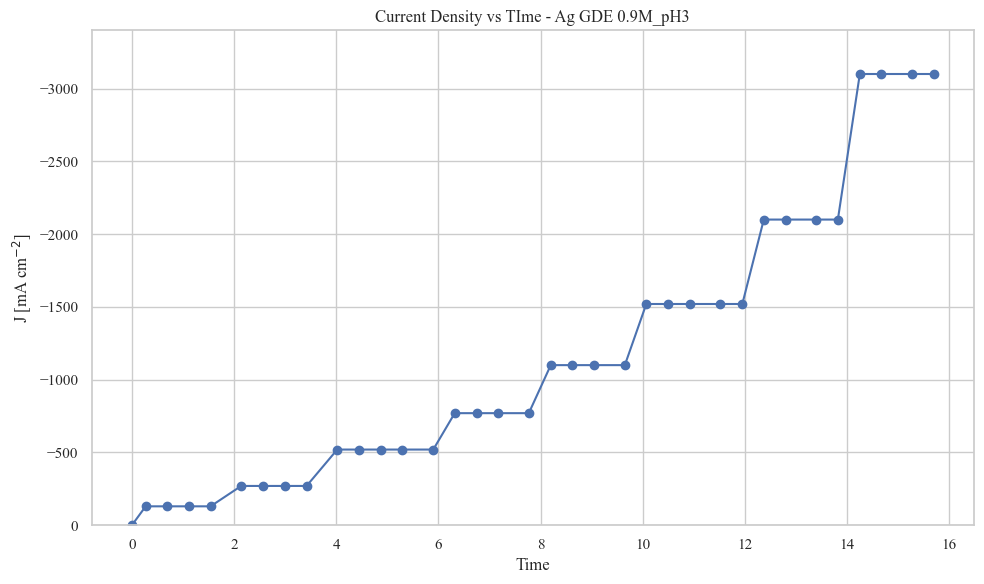

In [124]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH3')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

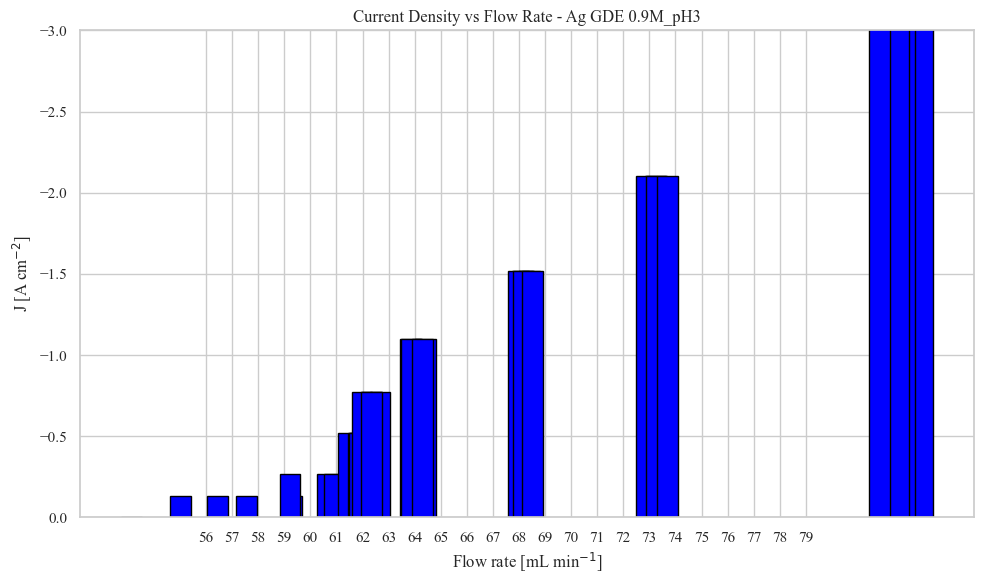

In [125]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH3')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


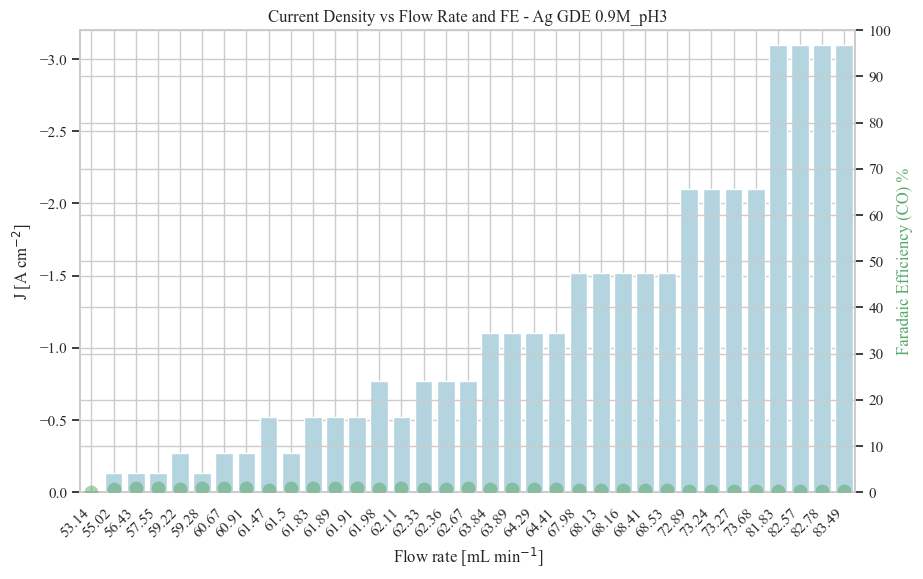

In [126]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH3')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240524_Ag_GDE_0_9M_pH3_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [127]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [128]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240524 - Ag60 GDE_0.9 M Na2SO4_pH3

11-Aug-26  08:35 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
07-Jun-26  12:55 PM    <DIR>          .ipynb_checkpoints
27-May-24  02:08 PM           110,661 0p9M_pH3 Na2SO4_20240527_1208_1min - Copy.xlsx
03-Aug-26  03:57 PM            79,065 0p9M_pH3 Na2SO4_20240527_1208_1min.xlsx
27-May-24  02:08 PM            26,807 0p9M_pH3 Na2SO4_20240527_1208_5min.xlsx
27-May-24  02:08 PM           479,886 0p9M_pH3 Na2SO4_20240527_1208_Line_1.csv
11-Aug-26  08:36 AM             1,411 20240424_0.9M Na2SO4_pH3_flow rate.csv
19-Jul-25  05:40 PM           838,176 20240524 - Ag60 GDE_0.9 M Na2SO4_pH3.ipynb
11-Aug-26  08:35 AM           836,680 20240524 - Ag60 GDE_0.9 M Na2SO4_pH3-CORRECTED.ipynb
11-Aug-26  08:36 AM               599 20240524_0.9 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  07:59 AM        

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


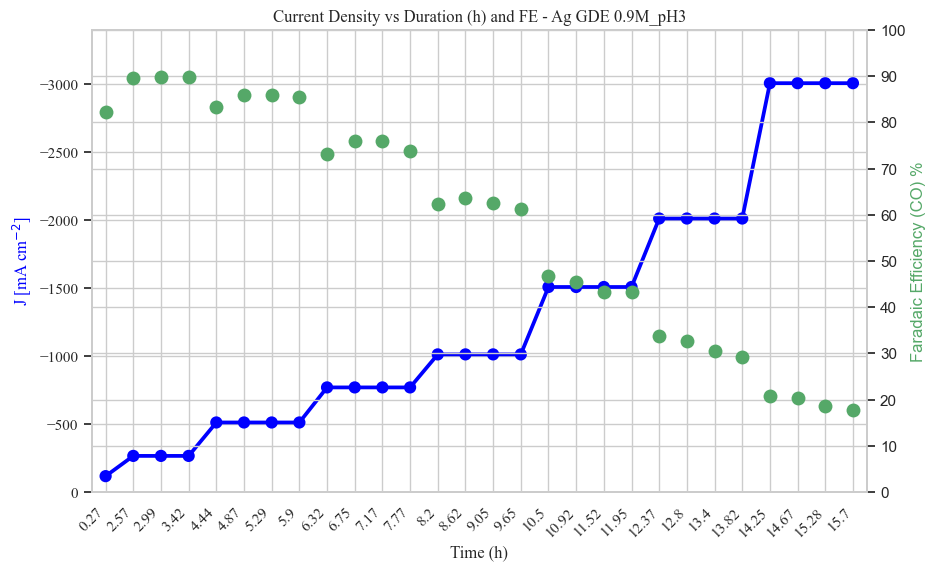

In [129]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH3')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240524_Ag_GDE_0_9M_pH3_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step in current

In [130]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 1.54].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.14].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.02].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.07].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,55.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.117,2024-05-24 16:04:16,0.27,0.073234,...,55.02,0.0,-117.0,0.13,0.117,57.972943,57.334368,58.520136,57.957787,86.642623
6,Ag60 GDE in PTFE holder,60,60.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:22:20,2.57,0.174282,...,60.67,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.316698
7,Ag60 GDE in PTFE holder,60,60.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 18:47:50,2.99,0.171676,...,60.91,2.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.587824
8,Ag60 GDE in PTFE holder,60,61.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.266,2024-05-24 19:13:20,3.42,0.170419,...,61.50,3.0,-266.0,0.27,0.266,59.128155,57.8498,60.288893,59.152551,94.555952
10,Ag60 GDE in PTFE holder,60,62.11,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:14:51,4.44,0.376590,...,62.11,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,88.809556
11,Ag60 GDE in PTFE holder,60,61.91,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 20:40:23,4.87,0.420141,...,61.91,4.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,91.984880
12,Ag60 GDE in PTFE holder,60,61.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 21:05:53,5.29,0.416608,...,61.83,5.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,92.104394
13,Ag60 GDE in PTFE holder,60,61.89,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.512,2024-05-24 21:41:55,5.90,0.412928,...,61.89,5.0,-512.0,0.52,0.512,60.085258,59.329101,61.087505,60.056291,91.421550
14,Ag60 GDE in PTFE holder,60,62.67,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.770,2024-05-24 22:58:28,7.17,1.223745,...,62.67,7.0,-770.0,0.77,0.770,60.653556,59.999044,62.672958,60.516597,88.086070
15,Ag60 GDE in PTFE holder,60,62.33,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.770,2024-05-24 23:34:29,7.77,1.341958,...,62.33,7.0,-770.0,0.77,0.770,60.653556,59.999044,62.672958,60.516597,86.986844


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

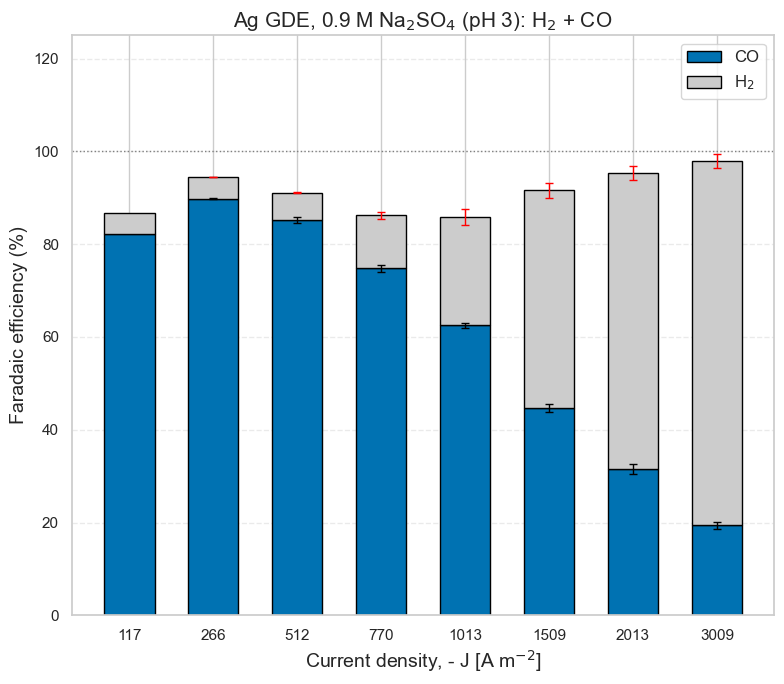

In [131]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

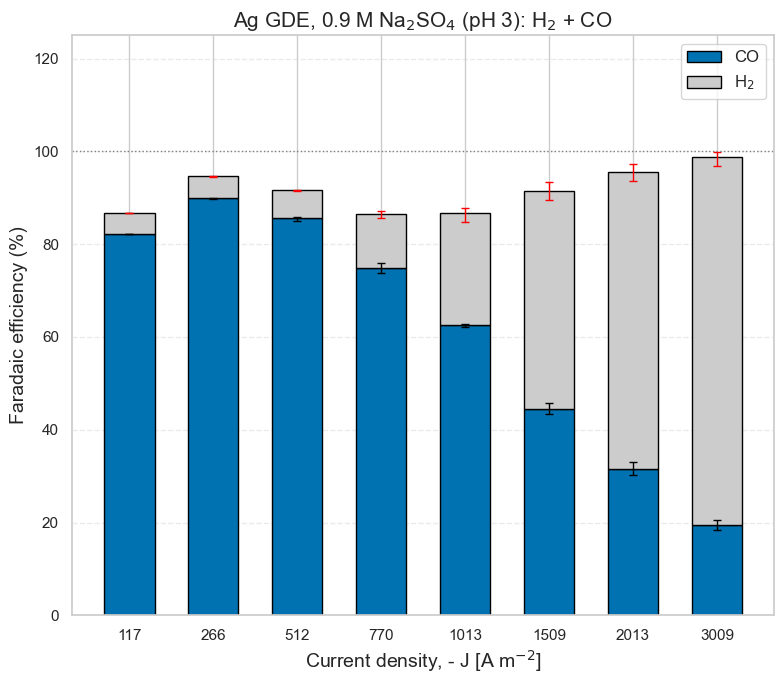

In [134]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [135]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [136]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.434986,82.207637,4.434986,82.207637,0.000000,0.000000,0.000000,0.000000,4.434986,...,0.000679,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,117
1,250,4.714043,89.772782,4.702906,89.884919,0.031105,0.114357,0.053875,0.198072,4.684756,...,0.001603,3,0.018149,0.034855,0.170418,0.002213,0.119627,0.015936,2–4,266
2,500,5.915577,85.164518,6.033115,85.644645,0.145701,0.626895,0.291402,1.253789,5.874307,...,0.003899,4,0.158807,0.041269,0.750401,0.270274,0.934664,0.311544,4–6,512
3,750,11.491386,74.760972,11.682518,74.867179,0.779006,0.713785,1.558011,1.427570,10.861017,...,0.011269,4,0.821501,0.630368,1.180747,1.074541,1.197320,0.337483,6–8,770
4,1000,23.292627,62.488031,24.208790,62.490891,1.735232,0.485578,3.470464,0.971155,22.229377,...,0.029925,4,1.979413,1.063250,0.395679,0.392818,1.784039,0.211009,8–10,1013
5,1500,46.842203,44.744225,47.030817,44.417768,1.575220,0.868029,3.150439,1.736059,44.988607,...,0.081096,4,2.042210,1.853596,1.066221,1.392679,0.649531,0.787375,10–12,1509
6,2000,63.676783,31.566220,63.946606,31.625146,1.509709,1.035107,3.019418,2.070215,61.989784,...,0.137052,4,1.956823,1.686999,1.394609,1.335683,0.621140,0.292391,12–14,2013
7,3000,78.498702,19.382839,79.206318,19.510876,1.479708,0.728025,2.959416,1.456051,77.321267,...,0.225441,4,1.885051,1.177435,1.081091,0.953054,0.931997,0.096345,14–16,3009


In [139]:
Res_Book
# Res_Book.to_csv('20240524_0.9M Na2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.434986,82.207637,4.434986,82.207637,0.000000,0.000000,0.000000,0.000000,4.434986,...,0.000679,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,117
1,250,4.714043,89.772782,4.702906,89.884919,0.031105,0.114357,0.053875,0.198072,4.684756,...,0.001603,3,0.018149,0.034855,0.170418,0.002213,0.119627,0.015936,2–4,266
2,500,5.915577,85.164518,6.033115,85.644645,0.145701,0.626895,0.291402,1.253789,5.874307,...,0.003899,4,0.158807,0.041269,0.750401,0.270274,0.934664,0.311544,4–6,512
3,750,11.491386,74.760972,11.682518,74.867179,0.779006,0.713785,1.558011,1.427570,10.861017,...,0.011269,4,0.821501,0.630368,1.180747,1.074541,1.197320,0.337483,6–8,770
4,1000,23.292627,62.488031,24.208790,62.490891,1.735232,0.485578,3.470464,0.971155,22.229377,...,0.029925,4,1.979413,1.063250,0.395679,0.392818,1.784039,0.211009,8–10,1013
5,1500,46.842203,44.744225,47.030817,44.417768,1.575220,0.868029,3.150439,1.736059,44.988607,...,0.081096,4,2.042210,1.853596,1.066221,1.392679,0.649531,0.787375,10–12,1509
6,2000,63.676783,31.566220,63.946606,31.625146,1.509709,1.035107,3.019418,2.070215,61.989784,...,0.137052,4,1.956823,1.686999,1.394609,1.335683,0.621140,0.292391,12–14,2013
7,3000,78.498702,19.382839,79.206318,19.510876,1.479708,0.728025,2.959416,1.456051,77.321267,...,0.225441,4,1.885051,1.177435,1.081091,0.953054,0.931997,0.096345,14–16,3009


## Mean and StD of FE(CO) through time

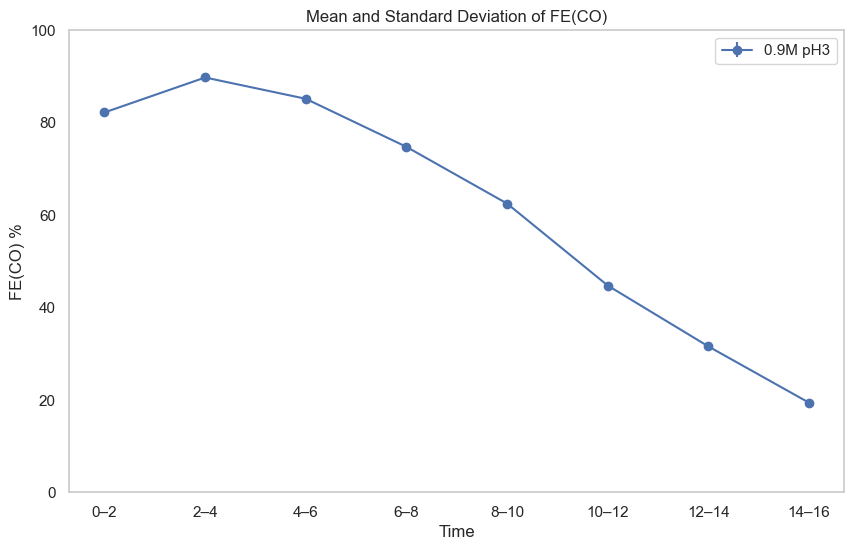

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.9M pH3')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240524_0.9M_pH3_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

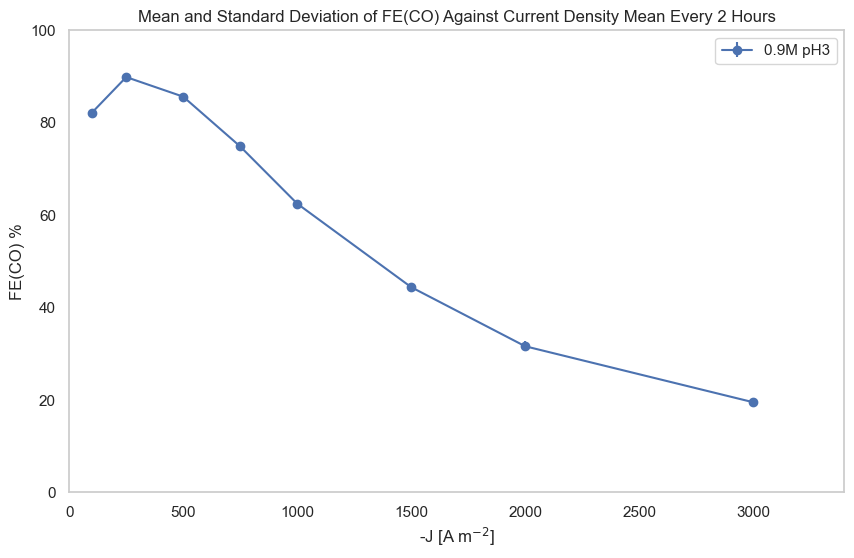

In [141]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_median'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.9M pH3')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240524_0.9M_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()